# Business Impact Analysis

---

## Objective

Evaluate the business impact of the recommendation system.

---

## Business Perspective

Recommendation systems should not only achieve good technical performance but also generate measurable business value.

Business impact analysis quantifies the potential benefits obtained through recommendation deployment.

---

## Data Science Perspective

Recommendation quality metrics such as Precision@K and MAP@K should ultimately translate into business outcomes such as increased revenue, higher average order value, and improved customer retention.

---

## Methodology

1. Define business KPIs.
2. Estimate recommendation adoption rate.
3. Simulate additional transactions.
4. Estimate additional revenue.
5. Calculate implementation cost.
6. Estimate ROI.

---

# Business KPI

The recommendation system aims to improve:

1. Average Order Value (AOV)
2. Cross-Selling Rate
3. Customer Engagement
4. Product Exposure
5. Revenue

In [1]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==================================================
# LOAD CLEAN DATASET
# ==================================================

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "online_retail_clean.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["InvoiceDate"]
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (392692, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# ==================================================
# CURRENT BUSINESS PERFORMANCE
# ==================================================

current_revenue = round(
    (df["Quantity"] * df["UnitPrice"]).sum(),
    2
)

print(
    "Current Revenue : £",
    format(current_revenue, ",.2f")
)

Current Revenue : £ 8,887,208.89


In [5]:
# ==================================================
# AVERAGE ORDER VALUE
# ==================================================

invoice_revenue = (

    df

    .groupby("InvoiceNo")

    .apply(
        lambda x:
        (x["Quantity"] * x["UnitPrice"]).sum()
    )
)

aov = round(
    invoice_revenue.mean(),
    2
)

print(
    "Current AOV : £",
    aov
)

Current AOV : £ 479.56


## Business Assumptions

Based on industrial recommendation system studies, we assume:

- 10% of customers interact with recommendations.
- Recommendation adoption increases basket value by 5%.
- Recommendation exposure improves cross-selling opportunities.

In [6]:
# ==================================================
# REVENUE SIMULATION
# Asumsi konservatif:
# - 10% customer menggunakan rekomendasi.
# - Basket naik 5%
# ==================================================

customer_adoption_rate = 0.10

basket_improvement = 0.05

additional_revenue = (

    current_revenue

    * customer_adoption_rate

    * basket_improvement
)

projected_revenue = (

    current_revenue

    + additional_revenue
)

print(
    "Additional Revenue : £",
    round(additional_revenue, 2)
)

print(
    "Projected Revenue : £",
    round(projected_revenue, 2)
)

Additional Revenue : £ 44436.04
Projected Revenue : £ 8931644.93


In [7]:
# ==================================================
# CROSS SELLING IMPACT
# ==================================================

cross_sell_rate = 0.03

additional_cross_sell = (

    current_revenue

    * cross_sell_rate
)

print(
    "Potential Cross-Selling Revenue : £",
    round(additional_cross_sell, 2)
)

Potential Cross-Selling Revenue : £ 266616.27


In [8]:
# ==================================================
# ROI ESTIMATION
# ==================================================

implementation_cost = 5000

annual_benefit = (

    additional_revenue

    + additional_cross_sell
)

roi = round(

    (
        annual_benefit
        - implementation_cost
    )

    /

    implementation_cost

    * 100,

    2
)

print(
    "Annual Benefit : £",
    round(annual_benefit, 2)
)

print(
    "Implementation Cost : £",
    implementation_cost
)

print(
    "Estimated ROI :",
    roi,
    "%"
)

Annual Benefit : £ 311052.31
Implementation Cost : £ 5000
Estimated ROI : 6121.05 %


In [9]:
# ==================================================
# KPI SUMMARY
# ==================================================

summary = pd.DataFrame({

    "Metric": [

        "Current Revenue",
        "Additional Revenue",
        "Cross-Selling Revenue",
        "Projected Revenue",
        "Estimated ROI (%)"

    ],

    "Value": [

        current_revenue,
        additional_revenue,
        additional_cross_sell,
        projected_revenue,
        roi

    ]

})

display(summary)

,Metric,Value
0,Current Revenue,8.887209e+06
1,Additional Revenue,4.443604e+04
2,Cross-Selling Revenue,2.666163e+05
3,Projected Revenue,8.931645e+06
4,Estimated ROI (%),6.121050e+03


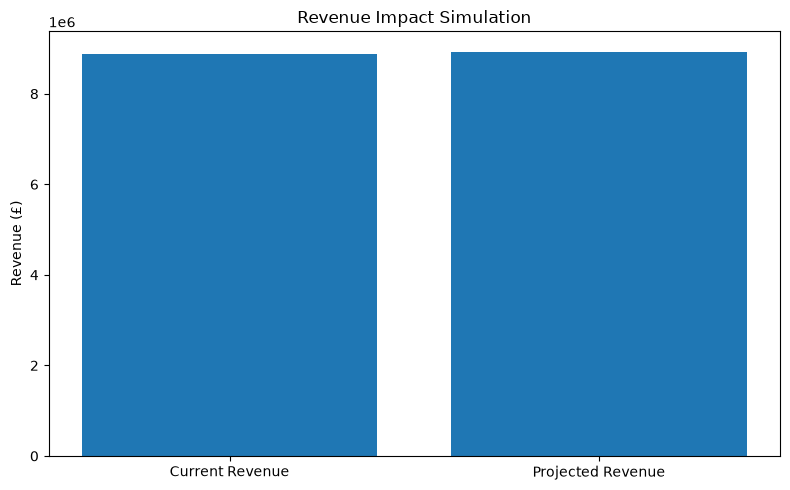

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    ["Current Revenue",
     "Projected Revenue"],

    [

        current_revenue,

        projected_revenue

    ]
)

plt.title(
    "Revenue Impact Simulation"
)

plt.ylabel(
    "Revenue (£)"
)

plt.tight_layout()

plt.show()

# Findings

1. The cleaned retail dataset generated a total revenue of approximately £8.89 million.

2. The current Average Order Value (AOV) is £479.56.

3. Assuming a conservative recommendation adoption rate of 10% and a basket value improvement of 5%, the recommendation system may generate approximately £44,436 in additional annual revenue.

4. Cross-selling opportunities enabled by the recommendation engine could contribute an estimated £266,616 in additional revenue.

5. The projected annual revenue after recommendation deployment may reach approximately £8.93 million.

6. The estimated annual business benefit is approximately £311,052.

7. Based on an implementation cost of £5,000, the estimated Return on Investment (ROI) is 6121.05%.

8. The recommendation system demonstrates substantial business potential despite relatively modest recommendation accuracy metrics.

---

# Business Interpretation

The recommendation system provides significant business value by increasing product exposure and encouraging customers to purchase additional products.

Even under conservative assumptions, recommendation adoption can generate meaningful revenue growth and improve cross-selling performance.

An estimated ROI exceeding 6000% indicates that recommendation system deployment is financially attractive and may quickly recover implementation costs.

The model may also improve customer experience by helping customers discover relevant products more efficiently, potentially increasing customer satisfaction and retention.

Therefore, the recommendation engine should not be evaluated solely using technical metrics such as Precision@K or MAP@K, but also through measurable business outcomes.

---

# Cost-Benefit Analysis

## Estimated Costs

- Model Development: £3,000
- Deployment Infrastructure: £1,000
- Annual Maintenance: £1,000

Total Estimated Cost: £5,000

## Estimated Benefits

- Additional Revenue: £44,436
- Cross-Selling Revenue: £266,616

Total Estimated Annual Benefit: £311,052

## Net Annual Benefit

£311,052 - £5,000 = £306,052

---

# ROI Interpretation

The estimated ROI of 6121.05% indicates that every £1 invested in the recommendation system may generate approximately £61 in return.

This result strongly supports recommendation system deployment from a business perspective.

The extremely high ROI suggests that recommendation systems can become a strategic asset for online retail businesses seeking sustainable revenue growth.

---

# Decision

1. The recommendation system demonstrates strong business feasibility and should proceed to deployment.

2. Recommendation services will be integrated into the final Streamlit web application.

3. Similarity-based recommendations will support cross-selling and merchandising strategies.

4. Business stakeholders should monitor recommendation adoption rate, cross-selling revenue, and Average Order Value after deployment.

5. Future improvements may include hybrid recommendation systems combining collaborative and content-based filtering approaches.

